## Entrenamiento final.

In [2]:
import pandas as pd
import numpy as np
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import json
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline

In [3]:
archivo = "CSVs/parámetros_columnas.json"

with open(archivo, "r") as f:
    datos = json.load(f)
    
mejores_parametros = datos["mejores_parametros"]
x_columnas = datos["x_columnas"]
y_columnas = datos["y_columnas"]

In [4]:
import json

with open("CSVs/parámetros_columnas_rf.json", "r") as f:
    datos_rf = json.load(f)

parametros_rf = datos_rf["mejores_parametros"]
x_columnas = datos_rf["x_columnas"]
y_columnas = datos_rf["y_columnas"]

In [5]:
from joblib import load

preprocess = load("CSVs/preprocess_rf.joblib")


In [6]:
train_viajeros = pd.read_csv("CSVs/train_viajeros.csv")
test_viajeros = pd.read_csv("CSVs/test_viajeros.csv")
prediccion_viajeros = pd.read_csv("CSVs/prediccion_viajeros.csv")
df_verano_viajeros = pd.read_csv("CSVs/verano_viajeros.csv")

In [7]:
categoricas_viajeros = [x_columnas.index("Provincias")]

Se filtra mayo en train y test. Se evaluan solamente los meses de verano.

In [8]:
train_viajeros = train_viajeros[train_viajeros["Mes"].isin([6,7,8])]
test_viajeros = test_viajeros[test_viajeros["Mes"].isin([6,7,8])]

In [9]:
x_train_viajeros = train_viajeros[x_columnas]
y_train_viajeros = train_viajeros[y_columnas]

x_test_viajeros = test_viajeros[x_columnas]
y_test_viajeros = test_viajeros[y_columnas]

## CatBoost

### Evaluación final sobre test.

In [10]:
modelo_test = CatBoostRegressor(
    iterations=1500,
    learning_rate=mejores_parametros["learning_rate"],
    depth =mejores_parametros["depth"] ,
    l2_leaf_reg=mejores_parametros["l2"] ,
    loss_function="RMSE",
    random_seed=42,
    early_stopping_rounds=100,
    verbose=0
)

modelo_test.fit(x_train_viajeros, y_train_viajeros, cat_features=categoricas_viajeros)

prediccion_log = modelo_test.predict(x_test_viajeros)

turistas_pasados = test_viajeros["Turistas_pasados"]
turistas_reales = test_viajeros["Turistas_totales"]

# Predicción CatBoost
ratio = np.exp(prediccion_log)
turistas_p = turistas_pasados * ratio

#Predicció Naive
prediccion_naive = turistas_pasados.fillna(0)


mae_viajeros = mean_absolute_error(turistas_reales, turistas_p)
rmse_viajeros = np.sqrt(mean_squared_error(turistas_reales, turistas_p))

mae_naive = mean_absolute_error(turistas_reales, prediccion_naive)
rmse_naive = np.sqrt(mean_squared_error(turistas_reales, prediccion_naive))

mape_viajeros = np.mean(np.abs(turistas_reales - turistas_p) / (turistas_reales + 1e-6))
precision_viajeros = 100 * (1-mape_viajeros)

mape_naive = np.mean(np.abs(turistas_reales - prediccion_naive) / (turistas_reales + 1e-6))
precision_naive = 100 * (1-mape_naive)

print(f"CATBOOST--- MAE: {mae_viajeros:.3f}, RMSE: {rmse_viajeros:.3f}, PRECISIÓN: {precision_viajeros:.2f}%")
print(f"NAIVE--- MAE: {mae_naive:.3f}, RMSE: {rmse_naive:.3f}, PRECISIÓN: {precision_naive:.2f}%")
      
if rmse_viajeros < rmse_naive:
    diferencia = rmse_naive - rmse_viajeros
    print(f"El modelo CatBoost es mejor.")
else:
    print(f"El modelo CatBoost no super al Naive.")

CATBOOST--- MAE: 5504.513, RMSE: 13776.764, PRECISIÓN: 92.01%
NAIVE--- MAE: 10376.410, RMSE: 23824.057, PRECISIÓN: 85.38%
El modelo CatBoost es mejor.


### RANDOM FOREST

In [11]:
rf_model = RandomForestRegressor(
    n_estimators=parametros_rf["n_estimators"],
    max_depth=parametros_rf["max_depth"],
    min_samples_leaf=parametros_rf["min_samples_leaf"],
    max_features=parametros_rf["max_features"],
    random_state=42,
    n_jobs=-1
)

rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocess),  
    ("model", rf_model)
])
rf_pipeline.fit(x_train_viajeros, y_train_viajeros)
prediccion_log_rf = rf_pipeline.predict(x_test_viajeros)

turistas_pasados = test_viajeros["Turistas_pasados"]
turistas_reales = test_viajeros["Turistas_totales"]

ratio_rf = np.exp(prediccion_log_rf)
turistas_p_rf = turistas_pasados * ratio_rf

mae_rf = mean_absolute_error(turistas_reales, turistas_p_rf)
rmse_rf = np.sqrt(mean_squared_error(turistas_reales, turistas_p_rf))

print(f"RANDOM FOREST--- MAE: {mae_rf:.3f}, RMSE: {rmse_rf:.3f}")


RANDOM FOREST--- MAE: 4049.644, RMSE: 6733.577


In [12]:
mask = turistas_pasados.notna() & turistas_reales.notna()
mape_rf = np.mean(np.abs(turistas_reales[mask] - turistas_p_rf[mask]) / (turistas_reales[mask] + 1e-6))
precision_rf = 100 * (1 - mape_rf)


In [13]:
print(f"CATBOOST--- MAE: {mae_viajeros:.3f}, RMSE: {rmse_viajeros:.3f}, PRECISIÓN: {precision_viajeros:.2f}%")
print(f"RANDOM FOREST--- MAE: {mae_rf:.3f}, RMSE: {rmse_rf:.3f}, PRECISIÓN: {precision_rf:.2f}%")
print(f"NAIVE--- MAE: {mae_naive:.3f}, RMSE: {rmse_naive:.3f}, PRECISIÓN: {precision_naive:.2f}%")


if rmse_viajeros < rmse_rf and rmse_viajeros < rmse_naive:
    print("El modelo CatBoost es el mejor de los tres.")
elif rmse_rf < rmse_viajeros and rmse_rf < rmse_naive:
    print("El modelo Random Forest es el mejor de los tres.")
else:
    print("\nEl modelo Naive es el mejor.")

CATBOOST--- MAE: 5504.513, RMSE: 13776.764, PRECISIÓN: 92.01%
RANDOM FOREST--- MAE: 4049.644, RMSE: 6733.577, PRECISIÓN: 91.59%
NAIVE--- MAE: 10376.410, RMSE: 23824.057, PRECISIÓN: 85.38%
El modelo Random Forest es el mejor de los tres.


### Entrenamiento final del modelo.

Entrenamiento final del modelo.

In [14]:
X_train = train_viajeros[x_columnas]
y_train = train_viajeros[y_columnas]

rf_model_final = RandomForestRegressor(
    n_estimators=parametros_rf["n_estimators"],
    max_depth=parametros_rf["max_depth"],
    min_samples_leaf=parametros_rf["min_samples_leaf"],
    max_features=parametros_rf["max_features"],
    random_state=42,
    n_jobs=-1
)

rf_pipeline_final = Pipeline(steps=[
    ("preprocessor", preprocess),
    ("model", rf_model_final)
])

rf_pipeline_final.fit(X_train, y_train)


,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('prov', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [15]:
import numpy as np


df_verano_viajeros = df_verano_viajeros.sort_values(["Provincias", "Año", "Mes"]).reset_index(drop=True)

meses_roll = [5, 6, 7, 8]

for mes in meses_roll:
    grupo = df_verano_viajeros.groupby("Provincias")["Turistas_totales"]

    
    df_verano_viajeros["Turistas_pasados"] = grupo.shift(1)

    for lag in [1, 2, 3, 4]:
        df_verano_viajeros[f"lag_{lag}"] = grupo.shift(lag)
        df_verano_viajeros[f"log_lag_{lag}"] = np.log1p(df_verano_viajeros[f"lag_{lag}"].fillna(0))

    df_verano_viajeros["media_lag_2"] = (df_verano_viajeros["log_lag_1"] + df_verano_viajeros["log_lag_2"]) / 2
    df_verano_viajeros["media_lag_3"] = (
        df_verano_viajeros["log_lag_1"] +
        df_verano_viajeros["log_lag_2"] +
        df_verano_viajeros["log_lag_3"]
    ) / 3
    df_verano_viajeros["tendencia_corta"] = df_verano_viajeros["log_lag_1"] - df_verano_viajeros["log_lag_2"]

    
    mask_mes = (df_verano_viajeros["Año"] == 2026) & (df_verano_viajeros["Mes"] == mes)

   
    pred_log_ratio = rf_pipeline_final.predict(df_verano_viajeros.loc[mask_mes, x_columnas])

    
    ratio = np.exp(pred_log_ratio)
    valor = df_verano_viajeros.loc[mask_mes, "Turistas_pasados"] * ratio

    
    df_verano_viajeros.loc[mask_mes, "Turistas_totales"] = valor


Predicción final.

In [16]:
# Se excluye el mes de mayo.
prediccion_verano_rf = (
    df_verano_viajeros[
        (df_verano_viajeros["Año"] == 2026) &
        (df_verano_viajeros["Mes"].isin([6, 7, 8]))
    ]
    .groupby("Provincias", as_index=False)["Turistas_totales"]
    .sum()
    .rename(columns={"Turistas_totales": "Predicciones"})
    .sort_values("Predicciones", ascending=False)
)

prediccion_verano_rf.head(10)


,Provincias,Predicciones
24,Illes Balears,6.500470e+06
7,Barcelona,3.705947e+06
31,Madrid,1.654982e+06
27,Las Palmas,1.308586e+06
19,Girona,1.230866e+06
34,Málaga,1.205963e+06
40,Santa Cruz de Tenerife,8.504494e+05
2,Alicante/Alacant,8.425335e+05
44,Tarragona,7.555161e+05
42,Sevilla,5.255780e+05


Visualización.

In [17]:
df_tabla = prediccion_verano_rf.copy()


df_tabla["Predicciones"] = df_tabla["Predicciones"].apply(
    lambda x: f"{x:,.0f}".replace(",", ".")
)


division = int(np.ceil(len(df_tabla) / 4))

columna_1 = df_tabla.iloc[:division].reset_index(drop=True)
columna_2 = df_tabla.iloc[division:2*division].reset_index(drop=True)
columna_3 = df_tabla.iloc[2*division:3*division].reset_index(drop=True)
columna_4 = df_tabla.iloc[3*division:].reset_index(drop=True)

df_tabla_final = pd.concat(
    [columna_1, columna_2, columna_3, columna_4],
    axis=1
)

df_tabla_final.columns = [
    "Provincias", "Turistas",
    "Provincias", "Turistas",
    "Provincias", "Turistas",
    "Provincias", "Turistas"
]

df_tabla_final


,Provincias,Turistas,Provincias,Turistas,Provincias,Turistas,Provincias,Turistas
0,Illes Balears,6.500.470,Granada,279.807,Córdoba,102.850,Ciudad Real,16.277
1,Barcelona,3.705.947,Cádiz,249.819,Castellón/Castelló,83.639,Jaén,15.646
2,Madrid,1.654.982,A Coruña,231.807,Huesca,79.881,Palencia,15.331
3,Las Palmas,1.308.586,Pontevedra,212.030,Valladolid,71.397,Ourense,14.839
4,Girona,1.230.866,Asturias,168.547,Lleida,69.513,Teruel,12.707
5,Málaga,1.205.963,Burgos,154.246,Araba/Álava,65.845,Albacete,11.563
6,Santa Cruz de Tenerife,850.449,Huelva,153.593,Badajoz,65.335,Ávila,11.395
7,Alicante/Alacant,842.533,Salamanca,135.852,Lugo,54.955,Ceuta,10.113
8,Tarragona,755.516,Zaragoza,134.045,Toledo,54.650,Melilla,9.098
9,Sevilla,525.578,Almería,134.004,León,54.012,Cuenca,8.275


In [27]:

ruta = "../graficos/tabla.md"

with open (ruta, "a", encoding= "utf-8") as f:
    f.write("\n\n")
    f.write(df_tabla_final.to_markdown(index=False))

In [28]:
df_tabla_final.to_excel("../graficos/tabla_random_forest_2026.xlsx", index=False)


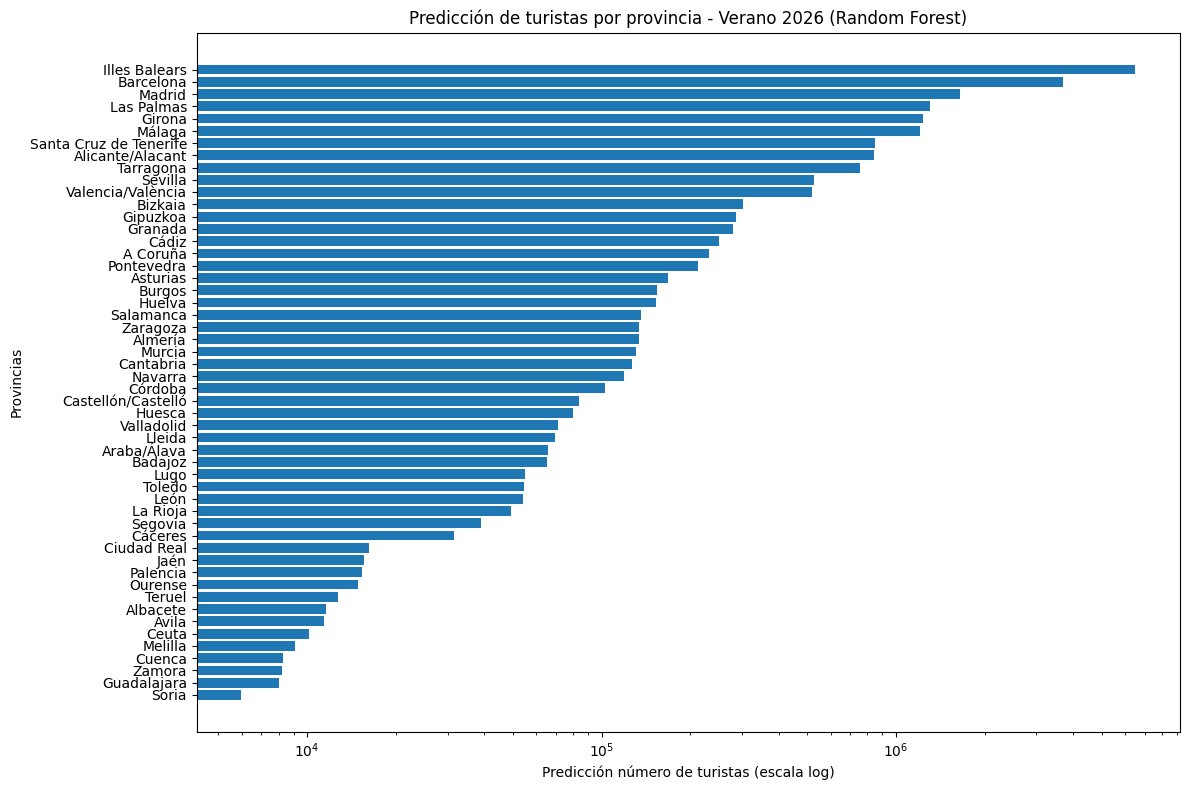

In [29]:
plt.figure(figsize=(12, 8))
plt.barh(prediccion_verano_rf["Provincias"][::-1], prediccion_verano_rf["Predicciones"][::-1])
plt.xscale("log")
plt.xlabel("Predicción número de turistas (escala log)")
plt.ylabel("Provincias")
plt.title("Predicción de turistas por provincia - Verano 2026 (Random Forest)")
plt.tight_layout()
plt.savefig("../graficos/grafico_random_forest_2026.png", dpi=300, bbox_inches="tight")
plt.show()